In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Iterable, Tuple
import pickle
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def normalize_unicode(text: str) -> str:
    """Normalize unicode while preserving substantive text."""
    if text is None:
        return ""
    return unicodedata.normalize("NFKC", text)


def normalize_whitespace(text: str) -> str:
    """Collapse excess whitespace but keep the special <newline> token intact."""
    if text is None:
        return ""
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_wp_prompt(prompt: str, remove_wp_tag: bool = True) -> str:
    """
    Clean a WritingPrompts source line.

    Parameters
    ----------
    prompt:
        Raw prompt line from *.wp_source.
    remove_wp_tag:
        Whether to remove leading tags like [ WP ].

    Returns
    -------
    Cleaned prompt string.
    """
    prompt = normalize_unicode(prompt)
    prompt = normalize_whitespace(prompt)

    if remove_wp_tag:
        prompt = re.sub(r"^\[\s*WP\s*\]\s*", "", prompt, flags=re.IGNORECASE)

    return prompt.strip()


def clean_wp_story(story: str, keep_newline_token: bool = True) -> str:
    """
    Clean a WritingPrompts target line.

    Parameters
    ----------
    story:
        Raw story line from *.wp_target.
    keep_newline_token:
        If True, preserve '<newline>' as a token. If False, convert it to actual newlines.

    Returns
    -------
    Cleaned story string.
    """
    story = normalize_unicode(story).strip()

    if keep_newline_token:
        # Ensure spacing around <newline> is consistent, then collapse whitespace.
        story = re.sub(r"\s*<newline>\s*", " <newline> ", story)
        story = normalize_whitespace(story)
    else:
        story = re.sub(r"\s*<newline>\s*", "\n", story)
        # Clean spaces around newlines without collapsing all newlines.
        story = re.sub(r"[ \t]+", " ", story)
        story = re.sub(r"\n{3,}", "\n\n", story).strip()

    return story


def render_story(story: str) -> str:
    """Convert stored '<newline>' tokens into human-readable paragraph breaks."""
    story = story.replace(" <newline> ", "\n")
    story = story.replace("<newline>", "\n")
    story = re.sub(r"\n{3,}", "\n\n", story)
    return story.strip()


def rough_word_count(text: str) -> int:
    """Approximate word count for tokenized WritingPrompts text."""
    text = text.replace("<newline>", " ")
    return len(re.findall(r"\b[\w']+\b", text))


def rough_sentence_count(text: str) -> int:
    """
    Approximate sentence count.

    This is intentionally simple and only for diagnostics / filtering.
    Later we can replace with spaCy or syntok if needed.
    """
    text = render_story(text)
    parts = re.split(r"[.!?]+(?:\s+|$)", text)
    return sum(1 for p in parts if p.strip())

In [3]:
@dataclass
class WritingPromptsCorpus:
    """
    Container for the WritingPrompts dataset.

    Core design:
    - `records` stores one row per prompt-story pair.
    - Prompts are assigned stable `prompt_id`s after cleaning.
    - Exact duplicate stories are retained because duplicates are part of the redundancy signal.
    - Splits are preserved so later analyses can choose train-only, all splits, or held-out prompts.
    """
    records: pd.DataFrame
    root_dir: str
    metadata: Dict = field(default_factory=dict)

    def __post_init__(self):
        required = {
            "pair_id", "split", "line_idx", "prompt_id", "prompt_raw", "prompt",
            "story_raw", "story", "prompt_word_count", "story_word_count",
            "story_sentence_count"
        }
        missing = required - set(self.records.columns)
        if missing:
            raise ValueError(f"records is missing required columns: {sorted(missing)}")

    @property
    def n_pairs(self) -> int:
        return len(self.records)

    @property
    def n_unique_prompts(self) -> int:
        return self.records["prompt_id"].nunique()

    def splits(self) -> List[str]:
        return sorted(self.records["split"].unique().tolist())

    def to_pickle(self, path: str | Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(self, f, protocol=pickle.HIGHEST_PROTOCOL)

    @staticmethod
    def from_pickle(path: str | Path) -> "WritingPromptsCorpus":
        with open(path, "rb") as f:
            return pickle.load(f)

    def get_records(
        self,
        split: Optional[str | Iterable[str]] = None,
        prompt_ids: Optional[Iterable[int]] = None,
        min_story_words: Optional[int] = None,
        max_story_words: Optional[int] = None,
        min_story_sentences: Optional[int] = None,
        max_story_sentences: Optional[int] = None,
    ) -> pd.DataFrame:
        """
        Return filtered records as a copy.
        """
        df = self.records

        if split is not None:
            if isinstance(split, str):
                split = [split]
            df = df[df["split"].isin(split)]

        if prompt_ids is not None:
            df = df[df["prompt_id"].isin(list(prompt_ids))]

        if min_story_words is not None:
            df = df[df["story_word_count"] >= min_story_words]

        if max_story_words is not None:
            df = df[df["story_word_count"] <= max_story_words]

        if min_story_sentences is not None:
            df = df[df["story_sentence_count"] >= min_story_sentences]

        if max_story_sentences is not None:
            df = df[df["story_sentence_count"] <= max_story_sentences]

        return df.copy()

    def prompt_summary(self, split: Optional[str | Iterable[str]] = None) -> pd.DataFrame:
        """
        Summarize response counts and story lengths by prompt.
        """
        df = self.get_records(split=split)

        summary = (
            df.groupby(["prompt_id", "prompt"], as_index=False)
              .agg(
                  n_responses=("story", "size"),
                  n_unique_story_texts=("story", "nunique"),
                  mean_story_words=("story_word_count", "mean"),
                  median_story_words=("story_word_count", "median"),
                  min_story_words=("story_word_count", "min"),
                  max_story_words=("story_word_count", "max"),
                  mean_story_sentences=("story_sentence_count", "mean"),
                  median_story_sentences=("story_sentence_count", "median"),
                  splits=("split", lambda x: ",".join(sorted(set(x)))),
              )
              .sort_values(["n_responses", "median_story_words"], ascending=[False, True])
              .reset_index(drop=True)
        )
        return summary

    def get_prompt_records(self, prompt_id: int) -> pd.DataFrame:
        """
        Return all stories for one prompt.
        """
        return (
            self.records[self.records["prompt_id"] == prompt_id]
            .sort_values(["split", "line_idx"])
            .copy()
        )

    def show_prompt_examples(
        self,
        prompt_id: int,
        n: int = 3,
        random_state: int = 42,
        max_chars: int = 1200,
    ) -> None:
        """
        Print a prompt and a few associated human stories.
        """
        df = self.get_prompt_records(prompt_id)
        if df.empty:
            print(f"No records found for prompt_id={prompt_id}")
            return

        prompt = df["prompt"].iloc[0]
        print(f"PROMPT ID: {prompt_id}")
        print(f"N human responses: {len(df)}")
        print("\nPROMPT:")
        print(prompt)

        sample = df.sample(n=min(n, len(df)), random_state=random_state)

        for i, (_, row) in enumerate(sample.iterrows(), start=1):
            story = render_story(row["story"])
            if len(story) > max_chars:
                story = story[:max_chars].rstrip() + " ..."
            print("\n" + "=" * 80)
            print(f"STORY EXAMPLE {i} | split={row['split']} | words={row['story_word_count']} | sentences={row['story_sentence_count']}")
            print("=" * 80)
            print(story)

In [4]:
def read_aligned_wp_split(
    root_dir: str | Path,
    split: str,
    keep_newline_token: bool = True,
) -> pd.DataFrame:
    """
    Read one WritingPrompts split from aligned source/target files.

    Expected files:
    - {split}.wp_source
    - {split}.wp_target

    Returns
    -------
    DataFrame with one row per prompt-story pair.
    """
    root_dir = Path(root_dir)
    source_path = root_dir / f"{split}.wp_source"
    target_path = root_dir / f"{split}.wp_target"

    if not source_path.exists():
        raise FileNotFoundError(f"Missing source file: {source_path}")
    if not target_path.exists():
        raise FileNotFoundError(f"Missing target file: {target_path}")

    with open(source_path, "r", encoding="utf-8") as f:
        source_lines = [line.rstrip("\n") for line in f]

    with open(target_path, "r", encoding="utf-8") as f:
        target_lines = [line.rstrip("\n") for line in f]

    if len(source_lines) != len(target_lines):
        raise ValueError(
            f"Line count mismatch for split={split}: "
            f"{len(source_lines)} source lines vs {len(target_lines)} target lines"
        )

    rows = []
    for line_idx, (prompt_raw, story_raw) in enumerate(zip(source_lines, target_lines)):
        prompt = clean_wp_prompt(prompt_raw)
        story = clean_wp_story(story_raw, keep_newline_token=keep_newline_token)

        rows.append(
            {
                "split": split,
                "line_idx": line_idx,
                "prompt_raw": prompt_raw,
                "prompt": prompt,
                "story_raw": story_raw,
                "story": story,
                "prompt_word_count": rough_word_count(prompt),
                "story_word_count": rough_word_count(story),
                "story_sentence_count": rough_sentence_count(story),
            }
        )

    return pd.DataFrame(rows)


def load_writing_prompts_corpus(
    root_dir: str | Path = "human_data/writingPrompts",
    splits: Tuple[str, ...] = ("train", "valid", "test"),
    keep_newline_token: bool = True,
) -> WritingPromptsCorpus:
    """
    Load all requested WritingPrompts splits into a reusable corpus object.
    """
    root_dir = Path(root_dir)

    split_dfs = []
    for split in splits:
        print(f"Loading split: {split}")
        split_df = read_aligned_wp_split(
            root_dir=root_dir,
            split=split,
            keep_newline_token=keep_newline_token,
        )
        split_dfs.append(split_df)
        print(f"  rows: {len(split_df):,}")

    records = pd.concat(split_dfs, ignore_index=True)

    # Stable integer prompt_id based on cleaned prompt text.
    # This groups repeated exact prompts across all splits if any exist.
    prompt_codes, prompt_uniques = pd.factorize(records["prompt"], sort=True)
    records["prompt_id"] = prompt_codes.astype(int)

    # Stable pair id for each prompt-story instance.
    records.insert(0, "pair_id", np.arange(len(records), dtype=int))

    # Reorder columns.
    cols = [
        "pair_id", "split", "line_idx", "prompt_id",
        "prompt_raw", "prompt",
        "story_raw", "story",
        "prompt_word_count", "story_word_count", "story_sentence_count",
    ]
    records = records[cols]

    metadata = {
        "root_dir": str(root_dir),
        "splits": list(splits),
        "keep_newline_token": keep_newline_token,
        "n_pairs": int(len(records)),
        "n_unique_prompts": int(records["prompt_id"].nunique()),
        "created_by": "load_writing_prompts_corpus",
    }

    corpus = WritingPromptsCorpus(
        records=records,
        root_dir=str(root_dir),
        metadata=metadata,
    )

    print("\nLoaded WritingPrompts corpus")
    print(f"  Total prompt-story pairs: {corpus.n_pairs:,}")
    print(f"  Unique cleaned prompts:   {corpus.n_unique_prompts:,}")
    print(f"  Splits:                   {corpus.splits()}")

    return corpus

In [5]:
# DATA_DIR = Path("human_data/writingPrompts")

# wp_corpus = load_writing_prompts_corpus(
#     root_dir=DATA_DIR,
#     splits=("train", "valid", "test"),
#     keep_newline_token=True,
# )

# wp_corpus.records.head()

Loading split: train
  rows: 272,600
Loading split: valid
  rows: 15,620
Loading split: test
  rows: 15,138

Loaded WritingPrompts corpus
  Total prompt-story pairs: 303,358
  Unique cleaned prompts:   108,190
  Splits:                   ['test', 'train', 'valid']


,pair_id,split,line_idx,prompt_id,prompt_raw,prompt,story_raw,story,prompt_word_count,story_word_count,story_sentence_count
0,0,train,0,68461,[ WP ] You 've finally managed to discover the...,You 've finally managed to discover the secret...,"So many times have I walked on ruins , the rem...","So many times have I walked on ruins , the rem...",39,573,22
1,1,train,1,51670,"[ WP ] The moon is actually a giant egg , and ...","The moon is actually a giant egg , and it has ...","-Week 18 aboard the Depth Reaver , Circa 2023-...","-Week 18 aboard the Depth Reaver , Circa 2023-...",14,483,73
2,2,train,2,78079,[ WP ] You find a rip in time walking through ...,You find a rip in time walking through the all...,"I was feckin ' sloshed , mate . First time I e...","I was feckin ' sloshed , mate . First time I e...",29,488,23
3,3,train,3,27454,[ WP ] For years in your youth the same imagin...,For years in your youth the same imaginary cha...,"“ No , no no no ... ” She backed up and turned...","“ No , no no no ... ” She backed up and turned...",40,484,52
4,4,train,4,78671,"[ WP ] You glance at your watch 10:34 am , rou...","You glance at your watch 10:34 am , roughly 10...",There 's a magical moment between wakefulness ...,There 's a magical moment between wakefulness ...,41,840,92


In [6]:
# CACHE_DIR = Path("human_data/cache")
# CACHE_DIR.mkdir(parents=True, exist_ok=True)

# pickle_path = CACHE_DIR / "writing_prompts_corpus.pkl"
# wp_corpus.to_pickle(pickle_path)

# print(f"Saved corpus pickle to: {pickle_path}")

Saved corpus pickle to: human_data/cache/writing_prompts_corpus.pkl


In [7]:
# Use this in future sessions instead of reloading the raw .wp_source / .wp_target files.

pickle_path = Path("human_data/cache/writing_prompts_corpus.pkl")
wp_corpus = WritingPromptsCorpus.from_pickle(pickle_path)

print(f"Reloaded corpus")
print(f"  Total prompt-story pairs: {wp_corpus.n_pairs:,}")
print(f"  Unique prompts:           {wp_corpus.n_unique_prompts:,}")
print(f"  Splits:                   {wp_corpus.splits()}")

Reloaded corpus
  Total prompt-story pairs: 303,358
  Unique prompts:           108,190
  Splits:                   ['test', 'train', 'valid']


In [8]:
def summarize_prompt_counts(corpus: WritingPromptsCorpus, split: Optional[str | Iterable[str]] = None) -> pd.DataFrame:
    """
    Count unique prompts and human response counts per prompt.
    """
    summary = corpus.prompt_summary(split=split)

    print("Prompt-count summary")
    print(f"  Rows / unique prompts: {len(summary):,}")
    print(f"  Total human responses: {summary['n_responses'].sum():,}")
    print()
    print(summary["n_responses"].describe(percentiles=[.5, .75, .9, .95, .99]))

    return summary


prompt_summary_all = summarize_prompt_counts(wp_corpus)
prompt_summary_all.head(20)

Prompt-count summary
  Rows / unique prompts: 108,190
  Total human responses: 303,358

count    108190.000000
mean          2.803938
std           4.180862
min           1.000000
50%           1.000000
75%           3.000000
90%           6.000000
95%           9.000000
99%          20.000000
max         177.000000
Name: n_responses, dtype: float64


,prompt_id,prompt,n_responses,n_unique_story_texts,mean_story_words,median_story_words,min_story_words,max_story_words,mean_story_sentences,median_story_sentences,splits
0,64836,"Write the letter that you always wanted to , b...",177,177,376.412429,293.0,101,2032,28.163842,21.0,valid
1,55265,There is no prompt . Just write a story you 'v...,146,146,834.575342,742.0,109,1897,65.561644,54.0,train
2,8866,A peaceful alien race is besieged by another r...,130,130,665.184615,597.0,150,1757,50.546154,45.0,"train,valid"
3,55728,This is the prologue ( or the first chapter ) ...,126,126,744.000000,627.0,129,1798,52.984127,43.5,train
4,62327,Write a short story where the first sentence h...,112,111,217.857143,215.0,190,276,20.357143,20.0,train
5,90069,[ CW ] Write the first and last paragraph of a...,111,111,218.639640,195.0,101,761,17.306306,15.0,train
6,37361,Killing Hitler has become a sport amongst time...,111,111,563.738739,488.0,103,1866,38.684685,35.0,train
7,81276,You live in a city full of people with powers ...,110,110,523.790909,418.0,111,1756,45.209091,35.0,train
8,104920,`` She said she loved him . '' Insert the word...,102,102,351.529412,250.0,99,1927,31.441176,20.0,train
9,56424,"To get in Heaven , you have to confront the pe...",98,98,689.316327,610.5,105,1813,71.683673,62.0,train


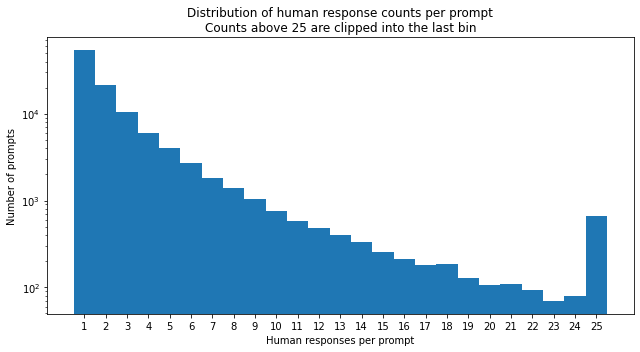

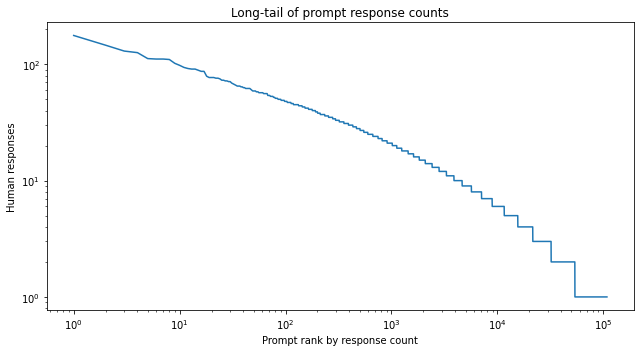

In [9]:
def plot_response_count_histogram(
    prompt_summary: pd.DataFrame,
    max_count_for_main_hist: int = 25,
    log_y: bool = True,
) -> None:
    """
    Plot the distribution of number of human responses per prompt.
    """
    counts = prompt_summary["n_responses"].values

    plt.figure(figsize=(9, 5))
    bins = np.arange(1, max_count_for_main_hist + 2) - 0.5
    plt.hist(np.clip(counts, 1, max_count_for_main_hist), bins=bins)
    plt.xlabel("Human responses per prompt")
    plt.ylabel("Number of prompts")
    plt.title(f"Distribution of human response counts per prompt\nCounts above {max_count_for_main_hist} are clipped into the last bin")
    if log_y:
        plt.yscale("log")
    plt.xticks(range(1, max_count_for_main_hist + 1))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    sorted_counts = np.sort(counts)[::-1]
    plt.plot(np.arange(1, len(sorted_counts) + 1), sorted_counts)
    plt.xlabel("Prompt rank by response count")
    plt.ylabel("Human responses")
    plt.title("Long-tail of prompt response counts")
    plt.yscale("log")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()


plot_response_count_histogram(prompt_summary_all, max_count_for_main_hist=25, log_y=True)

In [63]:
def find_candidate_story_prompts(
    corpus: WritingPromptsCorpus,
    split: Optional[str | Iterable[str]] = None,
    min_responses: int = 20,
    min_median_words: int = 100,
    max_median_words: int = 400,
    min_mean_sentences: int = 5,
    max_mean_sentences: int = 25,
    exclude_regex: Optional[str] = None,
) -> pd.DataFrame:
    """
    Find prompts with enough human responses and roughly suitable story length.

    This does not remove stories. It only helps identify candidate prompts.
    Later we can create a pilot subset with response-level filters.
    """
    summary = corpus.prompt_summary(split=split)

    candidates = summary[
        (summary["n_responses"] >= min_responses)
        & (summary["median_story_words"] >= min_median_words)
        & (summary["median_story_words"] <= max_median_words)
        & (summary["mean_story_sentences"] >= min_mean_sentences)
        & (summary["mean_story_sentences"] <= max_mean_sentences)
    ].copy()

    if exclude_regex:
        mask = candidates["prompt"].str.contains(exclude_regex, case=False, regex=True, na=False)
        candidates = candidates[~mask].copy()

    candidates = candidates.sort_values(
        ["n_responses", "median_story_words"],
        ascending=[False, True],
    ).reset_index(drop=True)

    print(f"Candidate prompts found: {len(candidates):,}")
    return candidates


# A first-pass exclusion list. Adjust after inspecting prompts.
exclude_regex = r"\b(harry potter|star wars|game of thrones|pokemon|marvel|dc comics|batman|superman|naruto|anime)\b"

candidate_prompts = find_candidate_story_prompts(
    wp_corpus,
    split=None,
    min_responses=20,
    min_median_words=0,
    max_median_words=4000,
    min_mean_sentences=5,
    max_mean_sentences=15,
    exclude_regex=exclude_regex,
)

candidate_prompts.head(30)

Candidate prompts found: 20


/var/folders/rj/l30_wb7d3w7_tbx4gbz6lzzh0000gn/T/ipykernel_7906/3362086322.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = candidates["prompt"].str.contains(exclude_regex, case=False, regex=True, na=False)


,prompt_id,prompt,n_responses,n_unique_story_texts,mean_story_words,median_story_words,min_story_words,max_story_words,mean_story_sentences,median_story_sentences,splits
0,46586,"Tell me an emotional story about a man , using...",62,62,189.983871,167.0,68,431,7.193548,4.0,train
1,22495,Describe an object within five feet of you in ...,56,56,191.785714,160.5,102,498,12.964286,10.0,valid
2,31626,"In 100 words or less , create a three dimensio...",46,46,129.934783,112.5,100,404,13.804348,11.0,train
3,63273,Write a story using only the suggestion button...,38,37,169.184211,134.5,101,721,10.473684,8.0,train
4,10491,A short Horror story . Something to chill the ...,35,35,115.600000,104.0,100,239,9.942857,10.0,train
5,99212,[ OT ] Writing Workshop # 36 - NaNo Prep # 1 :...,33,33,164.212121,148.0,103,440,8.393939,8.0,train
6,93742,[ FF ] 100 Words or Less - The parachute is n'...,32,32,119.968750,107.0,99,264,13.968750,14.0,train
7,107472,write a one paragraph summary of yourself with...,31,31,137.935484,124.0,100,342,9.774194,8.0,train
8,98363,[ OT ] ( Meta ) Let 's talk about fairness .,30,30,190.333333,175.0,103,325,10.766667,10.0,train
9,63555,Write a suicide note in a Dr. Suess like fashi...,26,26,167.769231,128.5,104,425,10.923077,8.0,train


In [85]:
# Change this index after looking at candidate_prompts.
candidate_row_idx = 19

prompt_id = int(candidate_prompts.loc[candidate_row_idx, "prompt_id"])
wp_corpus.show_prompt_examples(prompt_id=prompt_id, n=3, random_state=7, max_chars=1800)

PROMPT ID: 98809
N human responses: 20

PROMPT:
[ OT ] SatChat : What is the synopsis of that book you 've always wanted to write ?

STORY EXAMPLE 1 | split=train | words=484 | sentences=20
It 's not a book , but recently I 've been imagining and recording ideas for a comic I want to write . I have n't really found any books like this , but when I watch some of my favorites shows , I always quite enjoy all the quiet scenes ( most notably in an anime called Serial Experiments Lain ) . Scenes where the only talking is from the crowd , where the main character is waiting quietly on a train , where the audio of a conversation is tuned down because the camera is zoomed out and you hear more of the environment . As someone who is quiet and loves silence , these scenes feel very much natural in a sense . While most probably call it filler , I very much appreciate it . As an artist ( albeit , I pretty much just recently started to do it more seriously ) it has also influenced my writing in tha

In [86]:
def make_story_pilot_subset(
    corpus: WritingPromptsCorpus,
    prompt_ids: Iterable[int],
    min_story_words: Optional[int] = 80,
    max_story_words: Optional[int] = 350,
    min_story_sentences: Optional[int] = 4,
    max_story_sentences: Optional[int] = 20,
    max_responses_per_prompt: Optional[int] = None,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Create a pilot human story dataset for selected prompts.

    Notes
    -----
    - This preserves exact duplicate substantive stories.
    - Filtering is by length only, not by quality.
    - Optional downsampling can balance prompts for quick pilot work.
    """
    df = corpus.get_records(
        prompt_ids=prompt_ids,
        min_story_words=min_story_words,
        max_story_words=max_story_words,
        min_story_sentences=min_story_sentences,
        max_story_sentences=max_story_sentences,
    )

    if max_responses_per_prompt is not None:
        df = (
            df.groupby("prompt_id", group_keys=False)
              .apply(lambda x: x.sample(n=min(len(x), max_responses_per_prompt), random_state=random_state))
              .reset_index(drop=True)
        )

    df = df.sort_values(["prompt_id", "split", "line_idx"]).reset_index(drop=True)

    print("Pilot subset")
    print(f"  Prompts: {df['prompt_id'].nunique():,}")
    print(f"  Stories: {len(df):,}")
    print()
    print(df.groupby("prompt_id").agg(
        prompt=("prompt", "first"),
        n_stories=("story", "size"),
        median_words=("story_word_count", "median"),
        median_sentences=("story_sentence_count", "median"),
    ).sort_values("n_stories", ascending=False))

    return df


# Example: choose the top 3 candidate prompts for now.
selected_prompt_ids = [10491, 93742, 93855]# [46586, 10491, 94009] #candidate_prompts.head(3)["prompt_id"].astype(int).tolist()

story_pilot_df = make_story_pilot_subset(
    wp_corpus,
    prompt_ids=selected_prompt_ids,
    min_story_words=None,        # do not over-filter initially
    max_story_words=None,
    min_story_sentences=None,    # sentence counts are unreliable for prompt 46586
    max_story_sentences=None,
    max_responses_per_prompt=None,
    random_state=42,
)

selected_story_prompts = (
    story_pilot_df
    .groupby("prompt_id", as_index=False)
    .agg(
        prompt=("prompt", "first"),
        n_human_stories=("story", "size"),
        median_human_story_words=("story_word_count", "median"),
        mean_human_story_words=("story_word_count", "mean"),
        median_human_story_sentences=("story_sentence_count", "median"),
        mean_human_story_sentences=("story_sentence_count", "mean"),
    )
    .sort_values("prompt_id")
)

selected_story_prompts

Pilot subset
  Prompts: 3
  Stories: 87

                                                      prompt  n_stories  \
prompt_id                                                                 
10491      A short Horror story . Something to chill the ...         35   
93742      [ FF ] 100 Words or Less - The parachute is n'...         32   
93855      [ FF ] Describe 100 years of a character 's li...         20   

           median_words  median_sentences  
prompt_id                                  
10491             104.0              10.0  
93742             107.0              14.0  
93855             112.0              10.5  


,prompt_id,prompt,n_human_stories,median_human_story_words,mean_human_story_words,median_human_story_sentences,mean_human_story_sentences
0,10491,A short Horror story . Something to chill the ...,35,104.0,115.60000,10.0,9.942857
1,93742,[ FF ] 100 Words or Less - The parachute is n'...,32,107.0,119.96875,14.0,13.968750
2,93855,[ FF ] Describe 100 years of a character 's li...,20,112.0,115.60000,10.5,11.700000


In [87]:
PILOT_DIR = Path("human_data/pilot")
PILOT_DIR.mkdir(parents=True, exist_ok=True)

human_stories_pkl = PILOT_DIR / "writing_prompts_selected_human_stories.pkl"
human_stories_csv = PILOT_DIR / "writing_prompts_selected_human_stories.csv"
selected_prompts_csv = PILOT_DIR / "writing_prompts_selected_prompts.csv"

# Best local format for preserving Python/pandas objects cleanly
story_pilot_df.to_pickle(human_stories_pkl)

# Also save a human-readable CSV copy
story_pilot_df.to_csv(human_stories_csv, index=False)

# Prompt metadata is small, CSV is enough
selected_story_prompts.to_csv(selected_prompts_csv, index=False)

print("Saved:")
print(human_stories_pkl)
print(human_stories_csv)
print(selected_prompts_csv)

Saved:
human_data/pilot/writing_prompts_selected_human_stories.pkl
human_data/pilot/writing_prompts_selected_human_stories.csv
human_data/pilot/writing_prompts_selected_prompts.csv


In [88]:
story_pilot_df = pd.read_pickle("human_data/pilot/writing_prompts_selected_human_stories.pkl")
selected_story_prompts = pd.read_csv("human_data/pilot/writing_prompts_selected_prompts.csv")

print(story_pilot_df.shape)
selected_story_prompts

(87, 11)


,prompt_id,prompt,n_human_stories,median_human_story_words,mean_human_story_words,median_human_story_sentences,mean_human_story_sentences
0,10491,A short Horror story . Something to chill the ...,35,104.0,115.60000,10.0,9.942857
1,93742,[ FF ] 100 Words or Less - The parachute is n'...,32,107.0,119.96875,14.0,13.968750
2,93855,[ FF ] Describe 100 years of a character 's li...,20,112.0,115.60000,10.5,11.700000


In [93]:
story_pilot_df

,pair_id,split,line_idx,prompt_id,prompt_raw,prompt,story_raw,story,prompt_word_count,story_word_count,story_sentence_count
0,10880,train,10880,10491,[ WP ] A short Horror story . Something to chi...,A short Horror story . Something to chill the ...,I was running . Tree branches whipped past my ...,I was running . Tree branches whipped past my ...,15,110,8
1,11118,train,11118,10491,[ WP ] A short Horror story . Something to chi...,A short Horror story . Something to chill the ...,I breathed heavily under the covers . A creak ...,I breathed heavily under the covers . A creak ...,15,103,16
2,15787,train,15787,10491,[ WP ] A short Horror story . Something to chi...,A short Horror story . Something to chill the ...,I pound my fists against the old wooden door w...,I pound my fists against the old wooden door w...,15,131,13
3,28897,train,28897,10491,[ WP ] A short Horror story . Something to chi...,A short Horror story . Something to chill the ...,The town square sparkled like the 4th of July ...,The town square sparkled like the 4th of July ...,15,121,8
4,32611,train,32611,10491,[ WP ] A short Horror story . Something to chi...,A short Horror story . Something to chill the ...,"It had been a year since the accident , and no...","It had been a year since the accident , and no...",15,239,16
...,...,...,...,...,...,...,...,...,...,...,...
82,221430,train,221430,93855,[ FF ] Describe 100 years of a character 's li...,[ FF ] Describe 100 years of a character 's li...,He was always bitter and blamed others for his...,He was always bitter and blamed others for his...,24,111,13
83,223095,train,223095,93855,[ FF ] Describe 100 years of a character 's li...,[ FF ] Describe 100 years of a character 's li...,"100 exciting years , 239 stolen treasures and ...","100 exciting years , 239 stolen treasures and ...",24,113,11
84,232298,train,232298,93855,[ FF ] Describe 100 years of a character 's li...,[ FF ] Describe 100 years of a character 's li...,He though that he was a good man that he was l...,He though that he was a good man that he was l...,24,143,8
85,242622,train,242622,93855,[ FF ] Describe 100 years of a character 's li...,[ FF ] Describe 100 years of a character 's li...,It had been an adventure ; over before it trul...,It had been an adventure ; over before it trul...,24,110,10
